In [12]:
#imports
import math
import numpy as np
import torch

from matplotlib import pyplot as plt

from linear_simulation import TheorySimulator

In [2]:
#Define global constants that will be used throughout the simulations 
device = 'cuda'
P = 100000

n = 128
k = 64
m = 64

# LDFA Simulation for r >= m

In [3]:
X = torch.normal(0, 1, (n, P)).to(device)
W_gt = torch.normal(0, 1, (m, 32)) @ torch.normal(0, 1, (32, n)) / math.sqrt(64)
W_gt = W_gt.to(device)
y = W_gt @ X
sigma_io = (1/(P)) * (y @ X.T) 

U, sig_io, V_t = torch.linalg.svd(sigma_io)
sig_mat_io = U.T @ sigma_io @ V_t.T

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3533342/691296798.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
100%|██████████| 5000/5000 [00:03<00:00, 1401.58it/s]


tensor(1.4026e-05, device='cuda:0')


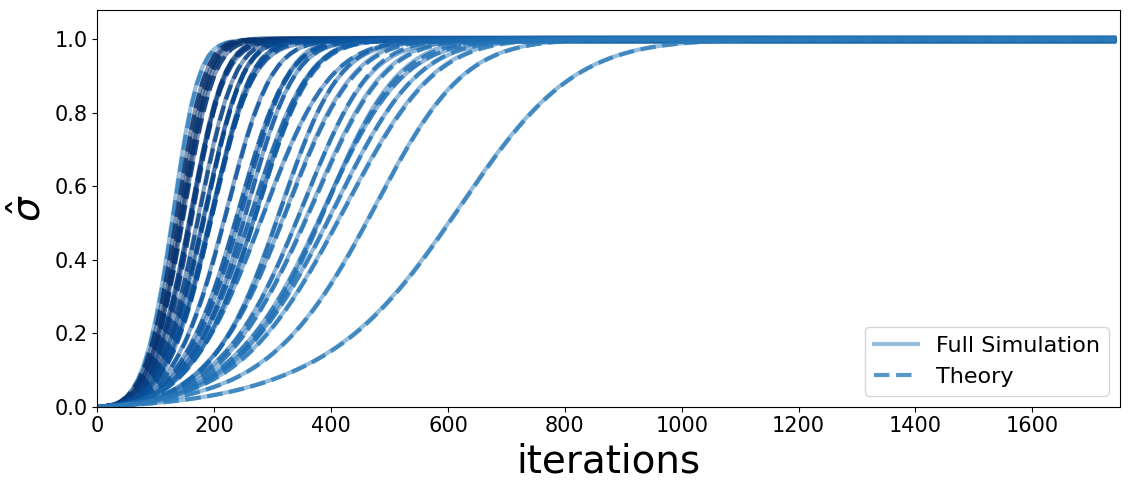

In [16]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=m, lr=4e-3, bw_lr=1.3e-3, lamb=1e-12, num_iterations=5000, update_QP=True, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 175
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=28)
axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
axs.set_xlim([0, 1750])
axs.set_ylim([0, 1.08])
axs.tick_params(axis='both', which='major', labelsize=15)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=16, ncol=1)

plt.tight_layout()
plt.savefig('normative_approach_r_equals_m.svg')
plt.savefig('normative_approach_r_equals_m.pdf')
plt.show()
plt.close()

# LDFA Simulation with r < m

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3533342/44626064.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
100%|██████████| 5000/5000 [00:03<00:00, 1427.21it/s]


tensor(4.7054, device='cuda:0')


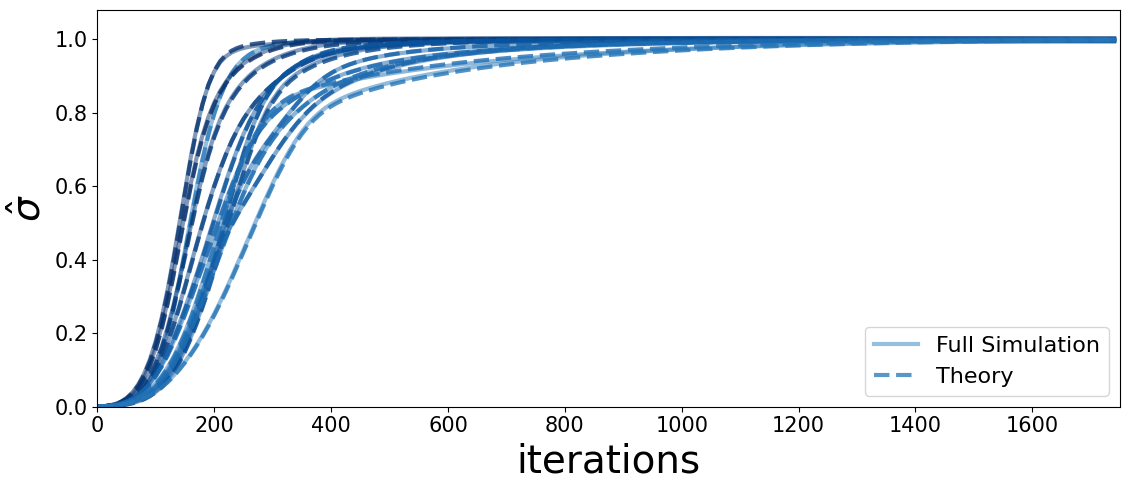

In [17]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=16, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, update_QP=True, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 14
lim = 175
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=blue_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=28)
axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
axs.set_xlim([0, 1750])
axs.set_ylim([0, 1.08])
axs.tick_params(axis='both', which='major', labelsize=15)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=16, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('normative_approach_r_less_than_m_r_16.pdf')
plt.savefig('normative_approach_r_less_than_m_r_16.svg')
plt.show()
plt.close()

# Simulation for r < m with FA 

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3533342/505937814.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
100%|██████████| 5000/5000 [00:03<00:00, 1522.00it/s]


tensor(15.5690, device='cuda:0')


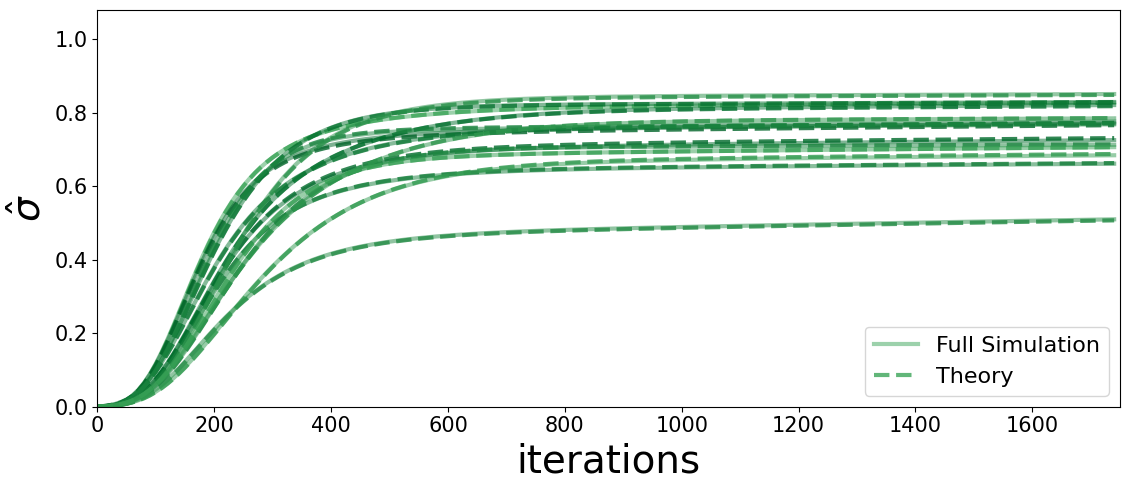

In [18]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=16, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, update_QP=False, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 14
lim = 175
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=28)
axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
axs.set_xlim([0, 1750])
axs.set_ylim([0, 1.08])
axs.tick_params(axis='both', which='major', labelsize=15)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=16, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('FA_r_less_than_m_r_16.pdf')
plt.savefig('FA_r_less_than_m_r_16.svg')
plt.show()
plt.close()

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3533342/883392519.py:21: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
100%|██████████| 5000/5000 [00:03<00:00, 1510.33it/s]


tensor(2.9544e-05, device='cuda:0')


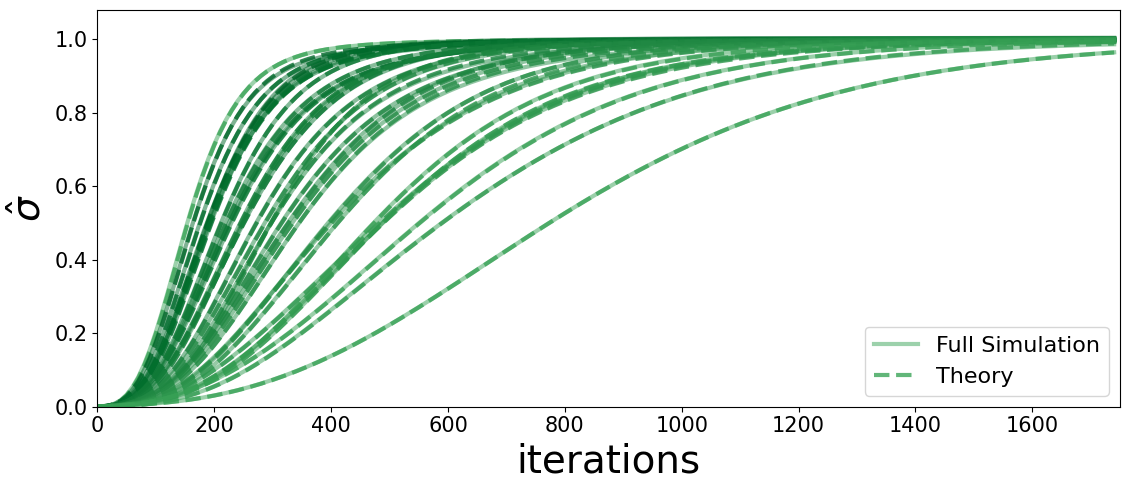

In [20]:
SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, rank=m, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, update_QP=False, device='cuda')
singulars_sim, singulars_theory = np.array(SimulationObj.train(X = X, y=y))

fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 175
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

X_range = np.arange(len(singulars_sim[:, 0])) * 10

for j in range(s):
    # ax.plot(singulars_BP[i, :, j], color=blue_colors[j], label='BP' if j == 0 else "")
    axs.plot(X_range[:lim], singulars_sim[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.5)
    axs.plot(X_range[:lim], singulars_theory[:lim, j] , color=green_colors[-j], linewidth=3, alpha=0.8, linestyle='--')
    # axs.plot(X[:lim], singulars_FA[:lim, j]  , color=green_colors[0], linewidth=2, linestyle='--')

axs.set_xlabel('iterations', fontsize=28)
axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
axs.set_xlim([0, 1750])
axs.set_ylim([0, 1.08])
axs.tick_params(axis='both', which='major', labelsize=15)
axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=16, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('FA_r_less_than_m_equals_r.pdf')
plt.savefig('FA_r_less_than_m_equals_r.svg')
plt.show()
plt.close()

# LDFA TOP singular as function of ranks

In [11]:
all_singulars_sim = []
all_singulars_theory = []
ranks = [1, 2, 4, 8, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]

for rank in ranks:
    print(f"\n--- Running simulation for rank={rank} ---")
    SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, 
                                    rank=rank, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, 
                                    update_QP=False, device='cuda')
    singulars_sim, singulars_theory = SimulationObj.train(X = X, y=y)
    
    all_singulars_sim.append(np.array(singulars_sim))
    all_singulars_theory.append(np.array(singulars_theory))

# Convert to numpy arrays for easier manipulation
all_singulars_sim = np.array(all_singulars_sim)  # Shape: (num_ranks, num_iterations, m)
all_singulars_theory = np.array(all_singulars_theory)  # Shape: (num_ranks, num_iterations, m)


--- Running simulation for rank=1 ---


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:03<00:00, 1546.94it/s]


tensor(42.7833, device='cuda:0')

--- Running simulation for rank=2 ---


100%|██████████| 5000/5000 [00:03<00:00, 1533.49it/s]


...

tensor(2.4889, device='cuda:0')

--- Running simulation for rank=30 ---


100%|██████████| 5000/5000 [00:03<00:00, 1509.06it/s]


tensor(1.0728, device='cuda:0')

--- Running simulation for rank=32 ---


100%|██████████| 5000/5000 [00:03<00:00, 1504.36it/s]

tensor(0.5797, device='cuda:0')


<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3533342/2824947675.py:17: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=28)


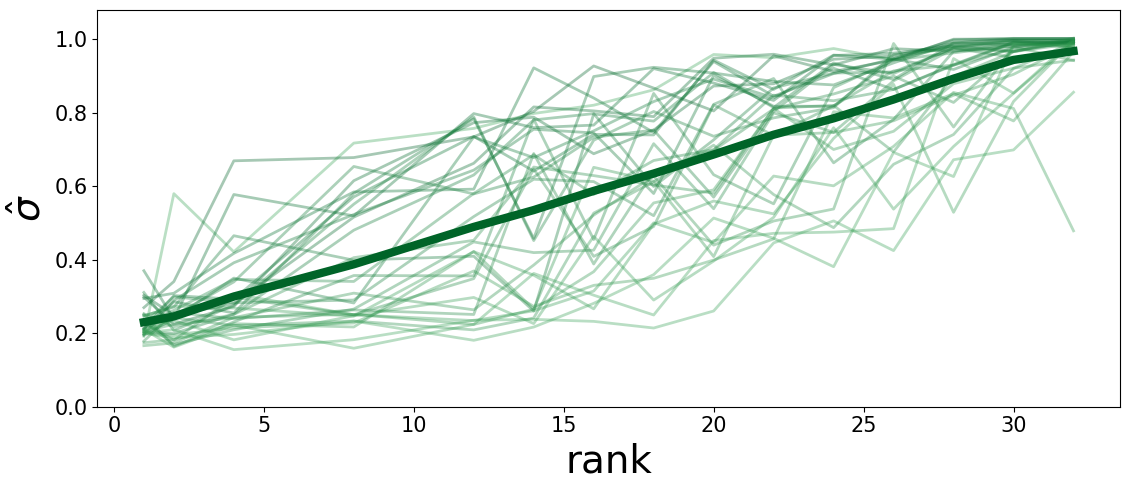

In [24]:
ranks = [1, 2, 4, 8, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]
fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 200
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

for j in range(s):
    plt.plot(ranks, all_singulars_sim[:, -1, j], color=green_colors[-j], alpha=0.35, linewidth=2)

plt.plot(ranks, all_singulars_sim[:, -1, :s].mean(-1), color=green_colors[-1], linewidth=6)


axs.set_xlabel('rank', fontsize=28)
axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
axs.set_ylim([0, 1.08])
axs.tick_params(axis='both', which='major', labelsize=15)
# axs.legend(['Full Simulation', 'Theory'], loc='lower right', fontsize=12, ncol=1)

plt.tight_layout()
# plt.show()
plt.savefig('FA_all_ranks.pdf')
plt.savefig('FA_all_ranks.svg')
plt.show()
plt.close()

In [23]:
all_singulars_sim_trainbackward = []
all_singulars_theory_trainbackward = []
ranks = [1, 2, 4, 8, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]

for rank in ranks:
    print(f"\n--- Running simulation for rank={rank} ---")
    SimulationObj = TheorySimulator(n, k, m, U=U, V_t = V_t, sig_mat_io = sig_mat_io, 
                                    rank=rank, lr=4e-3, bw_lr=1.3e-3, lamb=1e-15, num_iterations=5000, 
                                    update_QP=True, device='cuda')
    singulars_sim_trainbackward, singulars_theory = SimulationObj.train(X = X, y=y)
    
    all_singulars_sim_trainbackward.append(np.array(singulars_sim_trainbackward))
    all_singulars_theory_trainbackward.append(np.array(singulars_theory))

# Convert to numpy arrays for easier manipulation
all_singulars_sim_trainbackward = np.array(all_singulars_sim_trainbackward)  # Shape: (num_ranks, num_iterations, m)
all_singulars_theory_trainbackward = np.array(all_singulars_theory_trainbackward)  # Shape: (num_ranks, num_iterations, m)


--- Running simulation for rank=1 ---


100%|██████████| 5000/5000 [00:03<00:00, 1472.39it/s]


tensor(36.5094, device='cuda:0')

--- Running simulation for rank=2 ---


100%|██████████| 5000/5000 [00:03<00:00, 1435.03it/s]


tensor(30.8497, device='cuda:0')

--- Running simulation for rank=4 ---


...

tensor(0.5962, device='cuda:0')

--- Running simulation for rank=30 ---


100%|██████████| 5000/5000 [00:03<00:00, 1392.98it/s]


tensor(0.2335, device='cuda:0')

--- Running simulation for rank=32 ---


100%|██████████| 5000/5000 [00:03<00:00, 1391.86it/s]

tensor(6.9356e-06, device='cuda:0')


<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3533342/2987408886.py:16: SyntaxWarning: invalid escape sequence '\h'
  axs.set_ylabel('$\hat{\sigma}$', fontsize=28)


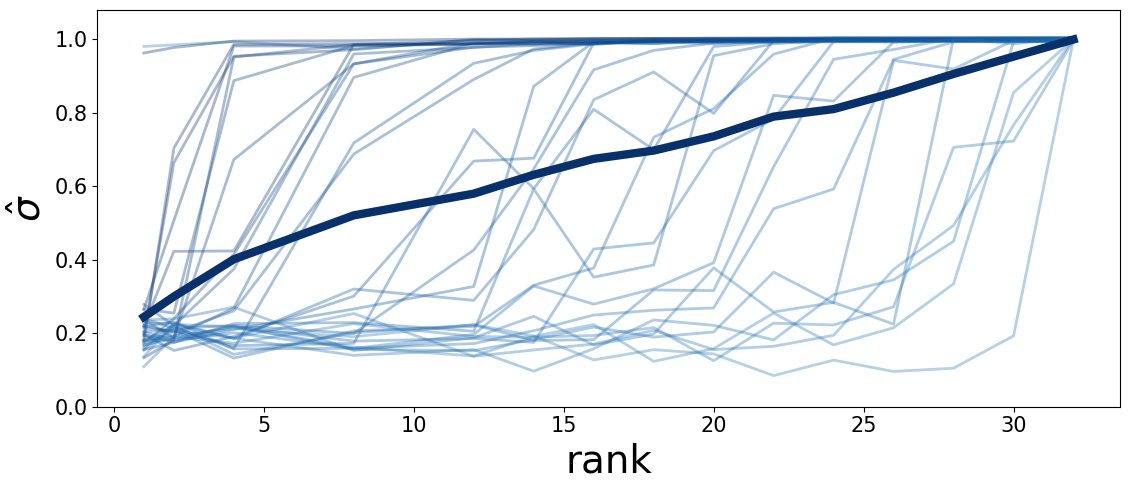

In [25]:
fig, axs = plt.subplots(1, 1, figsize=(11.4, 5)) 
s = 32
lim = 200
# Create color mapsac
blue_colors = plt.cm.Blues(np.linspace(0.7, 1,s))
green_colors = plt.cm.Greens(np.linspace(0.65, 0.9,s))
red_colors = plt.cm.Reds(np.linspace(0.4, 1,s))

for j in range(s):
    plt.plot(ranks, all_singulars_sim_trainbackward[:, -1, j], color=blue_colors[-j], alpha=0.35, linewidth=2)

plt.plot(ranks, all_singulars_sim_trainbackward[:, -1, :s].mean(-1), color=blue_colors[-1], linewidth=6)


axs.set_xlabel('rank', fontsize=28)
axs.set_ylabel('$\hat{\sigma}$', fontsize=28)
axs.set_ylim([0, 1.08])
axs.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.savefig('LDFA_all_ranks.pdf')
plt.savefig('LDFA_all_ranks.svg')
plt.show()